In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("output/combined_races.csv")
df = df[~df["Date"].isin(["2024-11-05", "2024-11-06"])]

In [24]:
df['Full_Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Timestamp'].astype(str))

# 2. Deduplicate: Keep only one row for each Race at each specific time
# This removes the redundant jurisdiction rows
df_unique = df.drop_duplicates(subset=['Race', 'Full_Timestamp']).copy()

# 3. Sort chronologically
df_unique = df_unique.sort_values(by=['Race', 'Full_Timestamp'])
df_unique

,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Jurisdiction,Unprocessed Ballots,Race,Full_Timestamp
1141,2024-11-07,17:37:00,82601,83241,0.003859,-0.000553,640,165842,609450.0,Riverside,350000.0,AD-47,2024-11-07 17:37:00
1142,2024-11-08,17:12:00,82601,83241,0.003859,0.000000,640,165842,586630.0,Riverside,350000.0,AD-47,2024-11-08 17:12:00
1143,2024-11-09,17:44:00,90634,90917,0.001559,-0.002300,283,181551,461630.0,Riverside,225000.0,AD-47,2024-11-09 17:44:00
1144,2024-11-11,17:07:00,92611,91946,0.003603,0.002044,665,184557,461630.0,Riverside,225000.0,AD-47,2024-11-11 17:07:00
1145,2024-11-12,08:08:00,97452,97183,0.001382,-0.002221,269,194635,364520.0,Riverside,165000.0,AD-47,2024-11-12 08:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,2024-11-29,18:55:00,167490,188044,0.057812,-0.000080,20554,355534,2311.0,Alameda,0.0,SD-5,2024-11-29 18:55:00
1018,2024-12-02,18:09:00,169089,189618,0.057231,-0.000581,20529,358707,0.0,Alameda,0.0,SD-5,2024-12-02 18:09:00
1019,2024-12-03,23:53:00,169136,189668,0.057223,-0.000007,20532,358804,0.0,Alameda,0.0,SD-5,2024-12-03 23:53:00
1020,2024-12-04,20:15:00,169136,189668,0.057223,0.000000,20532,358804,0.0,Alameda,0.0,SD-5,2024-12-04 20:15:00


In [27]:
df_unique = df_unique[df_unique['D_Share_Diff'] != 0.0]

# 4. Compute Democratic Share: D / (D + R)
df_unique['D_Share'] = df_unique['D'] / (df_unique['D'] + df_unique['R'])


# 5. Get the baseline share (the very first drop) for each race
df_unique['D_Share_First'] = df_unique.groupby('Race')['D_Share'].transform('first')

# 6. Compute the change relative to the first drop
df_unique['D_Share_Diff'] = df_unique['D_Share'] - df_unique['D_Share_First']
df_unique['Race_Mean_Diff'] = df_unique.groupby('Race')['D_Share_Diff'].transform('mean')
df_unique['D_Share_Centered'] = df_unique['D_Share_Diff'] - df_unique['Race_Mean_Diff']

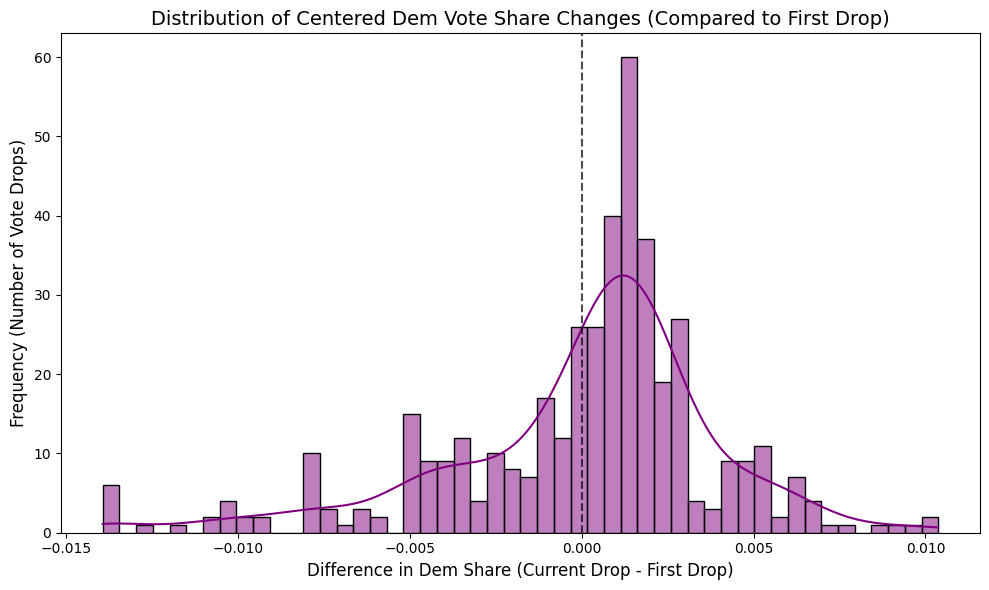

In [29]:
plt.figure(figsize=(10, 6))

# Filter out the first drops (which are exactly 0.0) so they don't skew the visual

# Create the histogram
# bins=50 controls the number of bars, kde=True adds a smoothed trendline
sns.histplot(data=df_unique, x='D_Share_Centered', bins=50, kde=True, color='purple')

# Formatting the chart
plt.title('Distribution of Centered Dem Vote Share Changes (Compared to First Drop)', fontsize=14)
plt.xlabel('Difference in Dem Share (Current Drop - First Drop)', fontsize=12)
plt.ylabel('Frequency (Number of Vote Drops)', fontsize=12)

# Add a vertical line at 0 for easy reference (no change)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()